In [33]:
import torch
import pandas as pd
import logomaker
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from collections import Counter

from modules.dna_tokenizer import DNATokenizer
from modules.custom_bert import DNABertForMaskedLM

In [34]:
# --- SETUP & LOADING ---

# Load Configuration
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device: ", device)

# Load Tokenizer
tokenizer = DNATokenizer()

# Load the trained model
model_path = "../model/test"
model = DNABertForMaskedLM.from_pretrained(model_path)
model.to(device)
model.eval()

# Load the Test Data
test_df = pd.read_parquet("../data/simulated/test.parquet")
print(f"Loaded {len(test_df)} test sequences.")

# Load the Motifs (Ground Truth)
with open("../data/simulated/motifs.txt", "r") as f:
    motifs = [line.strip() for line in f.readlines()]
MOTIF_A = motifs[0]
MOTIF_B = motifs[1]
print(f"Ground Truth Motifs:\nMotif A: {MOTIF_A}\nMotif B: {MOTIF_B}")

Using device:  mps
Loaded 2000 test sequences.
Ground Truth Motifs:
Motif A: ACTAGGT
Motif B: ATCTTA


In [35]:
# Baseline
# Count all tokens
all_tokens = []
for seq in test_df["sequences"]:
    all_tokens.extend(list(seq))

counts = Counter(all_tokens)
total = sum(counts.values())

# Calculate Frequencies
print("Token Distribution:")
for token, count in counts.items():
    print(f"{token}: {count/total:.2%}")

print(f"\n--- Baselines ---")
total_tokens = sum(counts.values())

random_baseline = 1 / len(counts)

most_common_token, most_common_count = counts.most_common(1)[0]
majority_baseline = most_common_count / total_tokens

print(f"Random Guess (1/{len(counts)}): {random_baseline:.2%}")
print(f"Majority Class (Always predict '{most_common_token}'): {majority_baseline:.2%}")

Token Distribution:
A: 25.13%
C: 22.02%
G: 21.79%
-: 3.90%
T: 27.16%

--- Baselines ---
Random Guess (1/5): 20.00%
Majority Class (Always predict 'T'): 27.16%


In [36]:
# --- Accuracy ---

def evaluate_accuracy(model, tokenizer, test_sequences, batch_size=16):
    """
    Standard masked accuracy on the test set.
    """
    model.eval()
    correct = 0
    total = 0

    # Simple dataset wrapper
    class TestDataset(Dataset):
        def __init__(self, seqs): self.seqs = seqs
        def __len__(self): return len(self.seqs)
        def __getitem__(self, i): return self.seqs[i]

    dataloader = DataLoader(TestDataset(test_sequences), batch_size=batch_size)

    print("Running quantitative evaluation...")
    with torch.no_grad():
        for batch_seqs in tqdm(dataloader):
            # 1. Tokenize
            encoded = tokenizer(batch_seqs, return_tensors="pt", padding="max_length", max_length=512)
            input_ids = encoded["input_ids"].to(device)
            attention_mask = encoded["attention_mask"].to(device)
            labels = input_ids.clone()

            # 2. Masking
            rand = torch.rand(input_ids.shape).to(device)
            mask_indices = (rand < 0.15) & (input_ids < 5) & (attention_mask == 1)
            input_ids[mask_indices] = tokenizer.mask_token_id

            # 3. Forward Pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            predictions = torch.argmax(outputs.logits, dim=-1)

            # 4. Calculate Accuracy
            correct += (predictions[mask_indices] == labels[mask_indices]).sum().item()
            total += mask_indices.sum().item()

    return correct / total

acc = evaluate_accuracy(model, tokenizer, test_df["sequences"].tolist())
print(f"\nTest Set Masked Accuracy: {acc:.2%}\n")

print(f"Random Guess (1/{len(counts)}): {random_baseline:.2%}")
print(f"Majority Class (Always predict '{most_common_token}'): {majority_baseline:.2%}")

Running quantitative evaluation...


100%|██████████| 125/125 [00:07<00:00, 15.65it/s]


Test Set Masked Accuracy: 28.21%

Random Guess (1/5): 20.00%
Majority Class (Always predict 'T'): 27.16%


Running Iterative Masking on 749 samples for ACTAGGT...


100%|██████████| 749/749 [00:22<00:00, 33.00it/s]


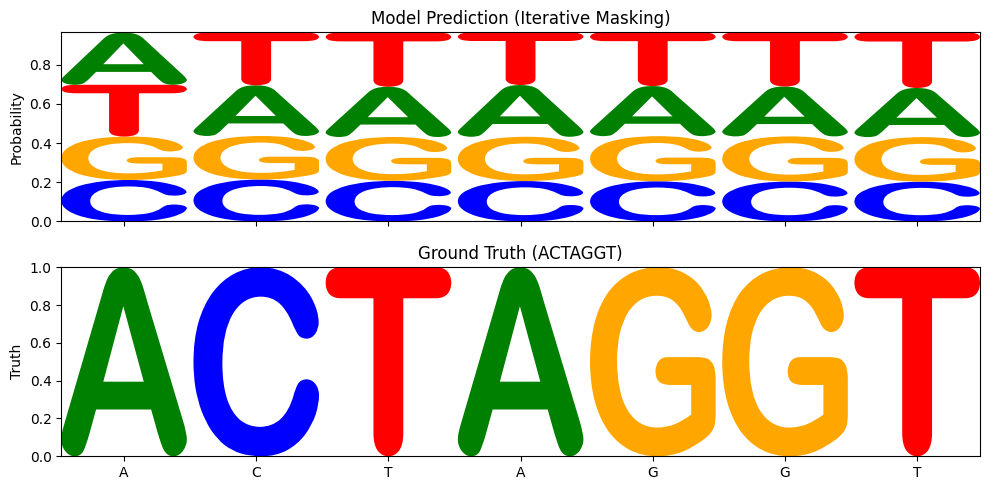

Running Iterative Masking on 749 samples for ATCTTA...


100%|██████████| 749/749 [00:19<00:00, 38.71it/s]


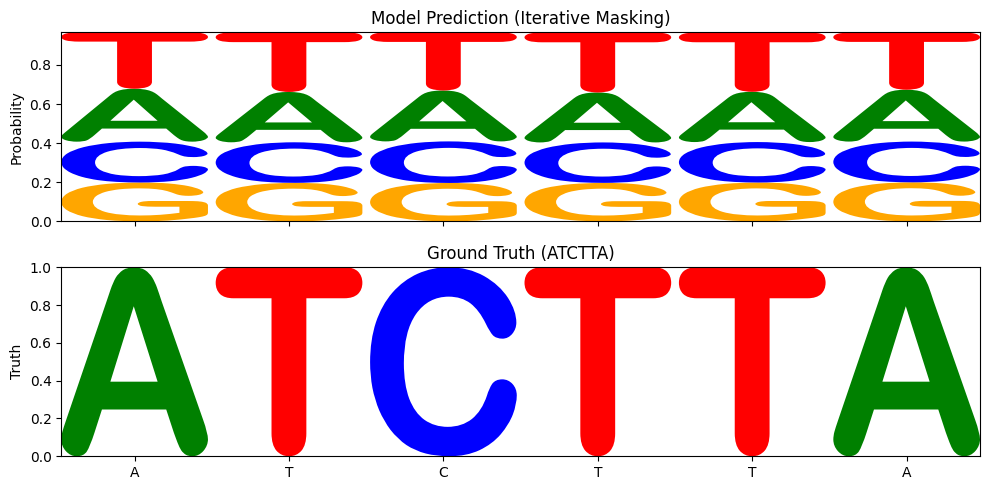

In [37]:
import numpy as np
import pandas as pd
import logomaker
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from tqdm import tqdm

def plot_iterative_masking_logo(model, tokenizer, sequences, motif_seq, title_prefix="Iterative Masking"):
    """
    Performs 'Saturation Reconstruction':
    For every instance of the motif, we iterate through its positions.
    We mask position 0 (keeping 1-9 visible), predict it.
    Then mask position 1 (keeping 0, 2-9 visible), predict it.

    This measures the model's ability to use LOCAL context (internal motif structure).
    """
    model.eval()

    motif_len = len(motif_seq)
    # We will store the average probability vector for each position
    # Shape: (motif_len, 4) -> 4 for A, C, G, T
    position_accumulators = np.zeros((motif_len, 4))
    position_counts = np.zeros(motif_len)

    print(f"Running Iterative Masking on {len(sequences)} samples for {motif_seq}...")

    # Standard DNA indices
    vocab_order = ["A", "C", "G", "T"]
    dna_ids = [tokenizer.tokens_to_ids[n] for n in vocab_order]

    for seq in tqdm(sequences):
        start_idx = seq.find(motif_seq)
        if start_idx == -1: continue

        # Tokenize ONCE for this sequence
        encoded = tokenizer(seq, return_tensors="pt")
        input_ids_original = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        # Absolute start index of motif (+1 for CLS)
        abs_start = start_idx + 1

        # Boundary check
        if abs_start + motif_len > input_ids_original.shape[1]: continue

        # --- ITERATIVE MASKING LOOP ---
        for i in range(motif_len):
            # Target absolute position
            target_pos = abs_start + i

            # Clone input and mask ONLY this one position
            input_ids_masked = input_ids_original.clone()
            input_ids_masked[0, target_pos] = tokenizer.mask_token_id

            # Predict
            with torch.no_grad():
                outputs = model(input_ids=input_ids_masked, attention_mask=attention_mask, return_dict=True)
                # Get logits for the TARGET position only
                logits = outputs.logits[0, target_pos]
                probs = F.softmax(logits, dim=-1)

            # Extract probabilities for A, C, G, T
            dna_probs = probs[dna_ids].cpu().numpy()

            # Accumulate
            position_accumulators[i] += dna_probs
            position_counts[i] += 1

    # --- AGGREGATE & PLOT ---
    if np.sum(position_counts) == 0:
        print("No valid motifs found.")
        return

    # Calculate Mean Probabilities
    # We divide each row by the count of samples (which should be constant, but safe to be explicit)
    mean_probs = position_accumulators / position_counts[:, None]

    # Create DataFrame for Logomaker
    df_logo = pd.DataFrame(mean_probs, columns=vocab_order)

    # Ground Truth Matrix for visual comparison
    ground_truth_matrix = np.zeros((motif_len, 4))
    for i, char in enumerate(motif_seq):
        if char in vocab_order:
            ground_truth_matrix[i, vocab_order.index(char)] = 1.0
    df_truth = pd.DataFrame(ground_truth_matrix, columns=vocab_order)

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

    # Model Prediction
    logo1 = logomaker.Logo(df_logo, ax=ax1, shade_below=.5, fade_below=.5, font_name='Arial Rounded MT Bold')
    ax1.set_title(f"Model Prediction (Iterative Masking)")
    ax1.set_ylabel("Probability")

    # Ground Truth
    logo2 = logomaker.Logo(df_truth, ax=ax2, shade_below=.5, fade_below=.5, font_name='Arial Rounded MT Bold')
    ax2.set_title(f"Ground Truth ({motif_seq})")
    ax2.set_ylabel("Truth")

    plt.xticks(range(motif_len), list(motif_seq))
    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
df_both = test_df[test_df['labels'] == 'both']

plot_iterative_masking_logo(
    model, tokenizer,
    sequences=df_both['sequences'].tolist(),
    motif_seq=MOTIF_A
)

plot_iterative_masking_logo(
    model, tokenizer,
    sequences=df_both['sequences'].tolist(),
    motif_seq=MOTIF_B
)